In [171]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

print('All the needed libraries imported successfully')

All the needed libraries imported successfully


In [172]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [173]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [174]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [175]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [176]:
df.shape

(7043, 21)

In [177]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [178]:
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [179]:
df.duplicated().sum()

np.int64(0)

**DATA CLEANING**

In [180]:
#We  do not need the customer id for our prediction so we remove it

In [181]:
df = df.drop(columns = 'customerID')

In [182]:
# We have to change the column datatype of Totalcharges from object to  numeric

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors = 'coerce')

In [183]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [184]:
df.TotalCharges.isna().sum()

np.int64(11)

In [185]:
df['TotalCharges']=df['TotalCharges'].fillna(df['TotalCharges'].median())

In [186]:
df['Churn'] = df['Churn'].map({'Yes':1,'No':0})
#Turning  the object churn column to numeric and mapping it yes or no with binary

**EDA**

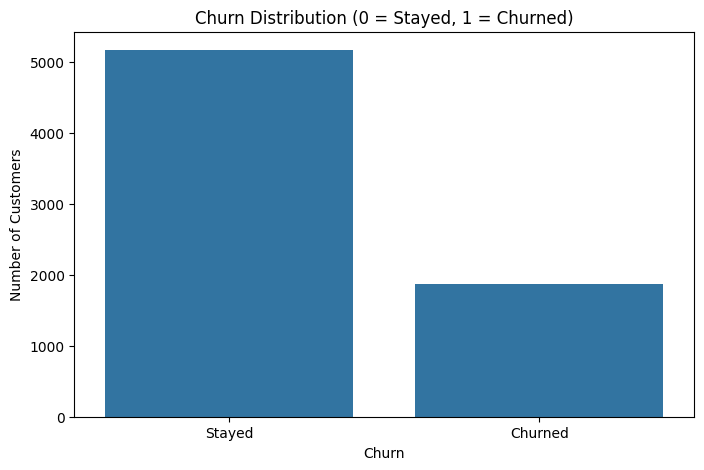

In [187]:
#Checking the target distribution

plt.figure(figsize=(8, 5))
churn_counts = df['Churn'].value_counts()
sns.barplot(x=churn_counts.index, y=churn_counts.values)
plt.title('Churn Distribution (0 = Stayed, 1 = Churned)')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.xticks([0, 1], ['Stayed', 'Churned'])
plt.show()

In [188]:
churn_rate = df['Churn'].mean() *100
print(f" Overall Churn Rate: {churn_rate:.2f}%")

 Overall Churn Rate: 26.54%


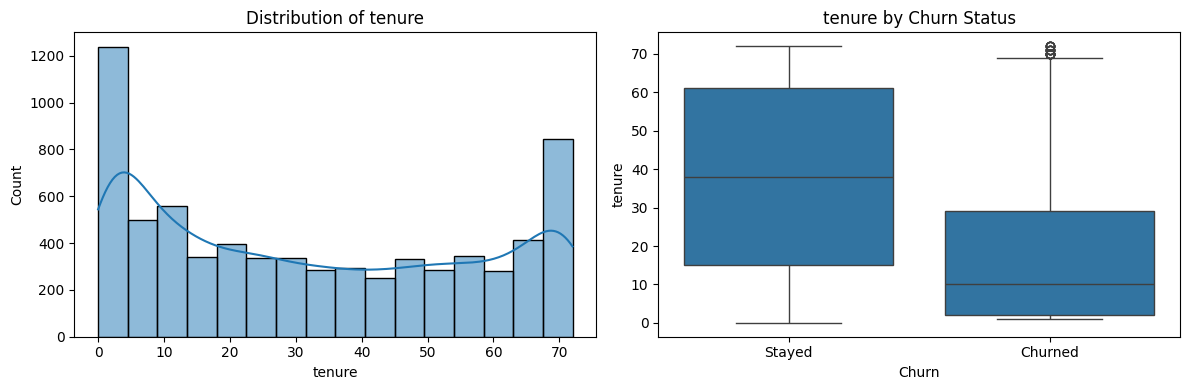

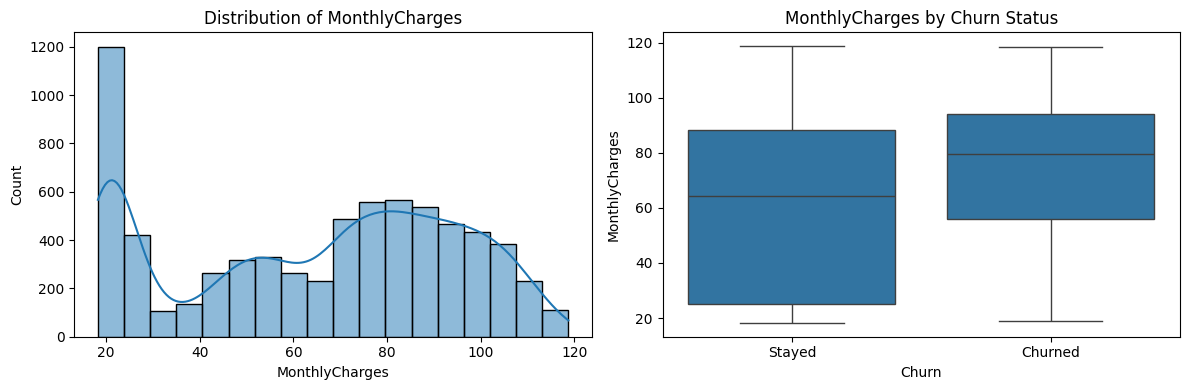

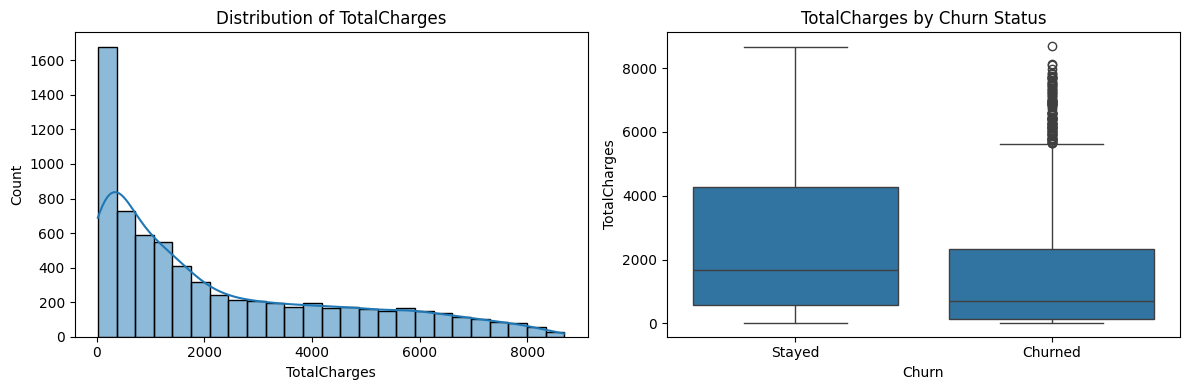

In [189]:
# Numerical Feature Analysis
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f'Distribution of {col}')

    # Boxplot by Churn
    sns.boxplot(x='Churn', y=col, data=df, ax=axes[1])
    axes[1].set_title(f'{col} by Churn Status')
    axes[1].set_xticklabels(['Stayed', 'Churned'])

    plt.tight_layout()
    plt.show()


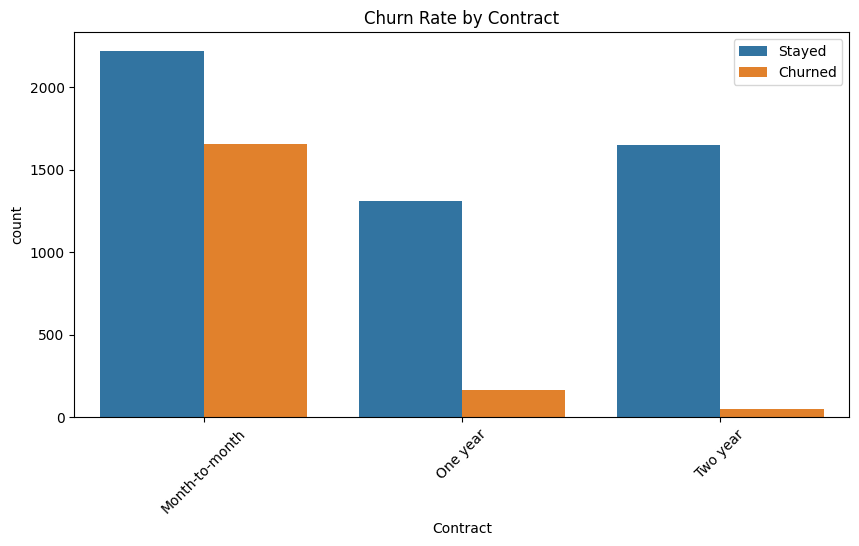

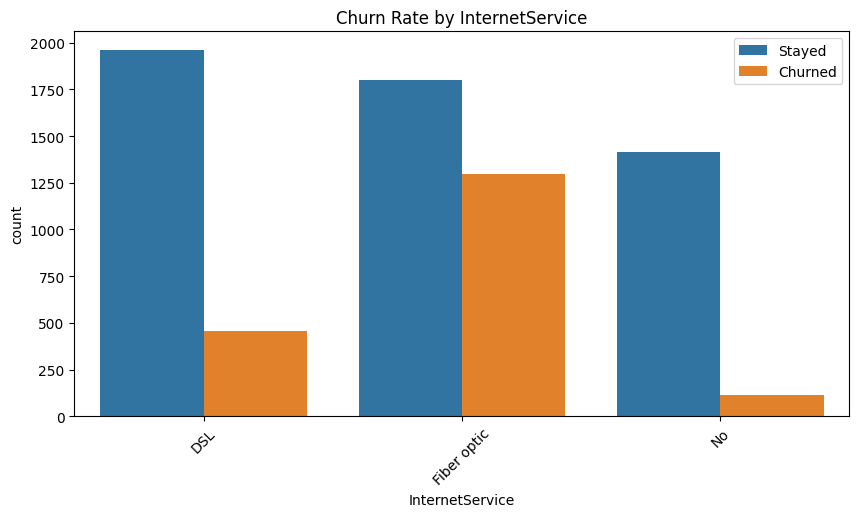

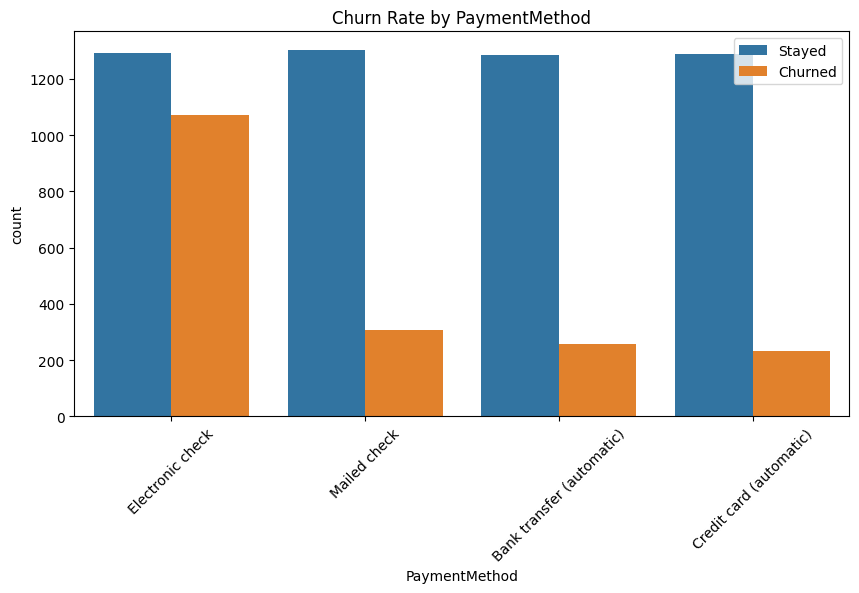

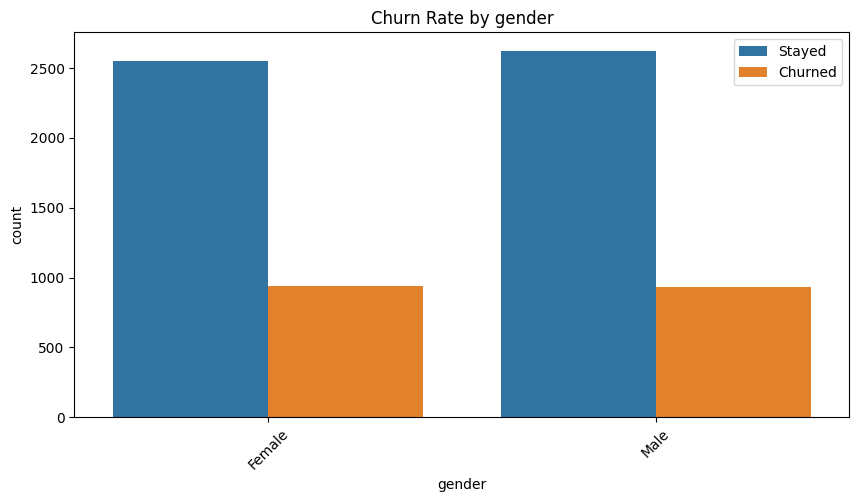

In [190]:
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'gender']

for col in cat_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(x=col, hue='Churn', data=df)
    plt.title(f'Churn Rate by {col}')
    plt.legend(['Stayed', 'Churned'])
    plt.xticks(rotation=45)
    plt.show()

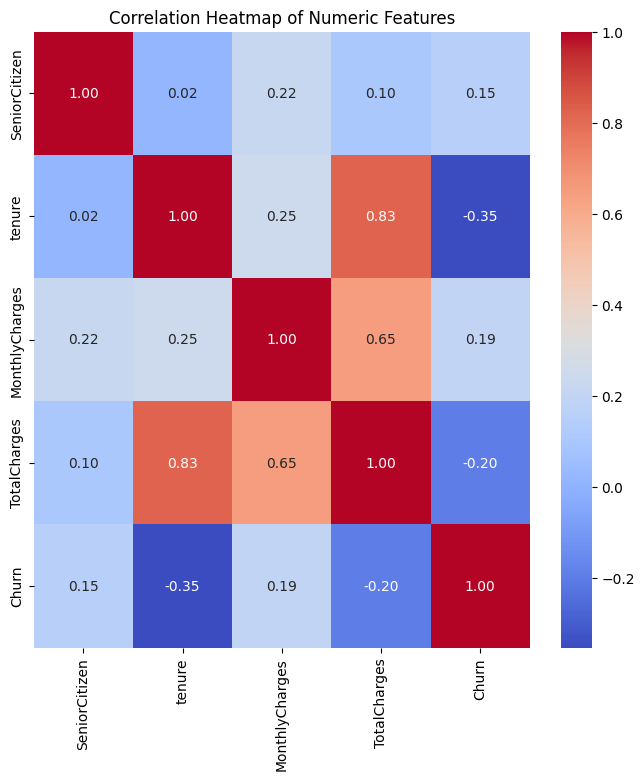

In [191]:
#Correlation Heatmap to find co relation between the numeric columns

plt.figure(figsize=(8, 8))

numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

In [192]:
# lets count how many services they have (excluding PhoneService which is basic)
service_cols = ['PhoneService', 'MultipleLines', 'InternetService',
                'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']

In [193]:
#For simplicity, we count services where the value is 'Yes' or not 'No' / 'No internet service'

df_service = df[service_cols].copy()

# Lets replace 'No internet service' and 'No phone service' with 'No' for consistency
for col in df_service.columns:
    df_service[col] = df_service[col].replace({
        'No internet service': 'No',
        'No phone service': 'No'
    })

In [194]:
df['TotalServices'] = (df_service == 'Yes').sum(axis=1)

In [195]:
print(df['TotalServices'].value_counts().sort_index())

TotalServices
0      80
1    1701
2    1188
3     965
4     922
5     908
6     676
7     395
8     208
Name: count, dtype: int64


In [196]:
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 36, 48, 60, 72],
    labels=['0-12M', '13-24M', '25-36M', '37-48M', '49-60M', '61-72M'])

# In this step we create tenure groups

**x and y split**

In [197]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [198]:
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"\nCategorical columns: {categorical_cols}")
print(f" Numerical columns: {numerical_cols}")


Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
 Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'TotalServices']


In [199]:
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

**TRAIN-TEST SPLIT & SCALING**

In [200]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

In [201]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5634 entries, 2142 to 860
Data columns (total 32 columns):
 #   Column                                 Non-Null Count  Dtype   
---  ------                                 --------------  -----   
 0   SeniorCitizen                          5634 non-null   int64   
 1   tenure                                 5634 non-null   int64   
 2   MonthlyCharges                         5634 non-null   float64 
 3   TotalCharges                           5634 non-null   float64 
 4   TotalServices                          5634 non-null   int64   
 5   tenure_group                           5624 non-null   category
 6   gender_Male                            5634 non-null   bool    
 7   Partner_Yes                            5634 non-null   bool    
 8   Dependents_Yes                         5634 non-null   bool    
 9   PhoneService_Yes                       5634 non-null   bool    
 10  MultipleLines_No phone service         5634 non-null   bool    

In [202]:
sc = StandardScaler()

X_train_scaled = sc.fit_transform(X_train.drop(columns=['tenure_group']))
X_test_scaled = sc.fit_transform(X_test.drop(columns=['tenure_group']))

# Drop 'tenure_group' column as it's categorical and not scaled by StandardScaler.

In [203]:
print(f" Original Training Set - Churn Rate: {y_train.mean()*100:.2f}%")

# Apply SMOTE to oversample the minority class (churners)
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f"Balanced Training Set - Churn Rate: {y_train_balanced.mean()*100:.2f}%")
print(f"SMOTE applied! New training set size: {X_train_balanced.shape}")


 Original Training Set - Churn Rate: 26.55%
Balanced Training Set - Churn Rate: 50.00%
SMOTE applied! New training set size: (8276, 31)


In [204]:
# Building model

In [205]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_balanced, y_train_balanced)

LogisticRegression(max_iter=1000, random_state=42)

In [206]:
y_pred_lr = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

In [207]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_proba_lr)

print(f"Logistic Regression - Accuracy: {accuracy_lr:.4f}")
print(f"Logistic Regression - ROC-AUC: {roc_auc_lr:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Stayed', 'Churned']))


Logistic Regression - Accuracy: 0.7559
Logistic Regression - ROC-AUC: 0.8609

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.92      0.73      0.81      1036
     Churned       0.52      0.83      0.64       373

    accuracy                           0.76      1409
   macro avg       0.72      0.78      0.73      1409
weighted avg       0.82      0.76      0.77      1409



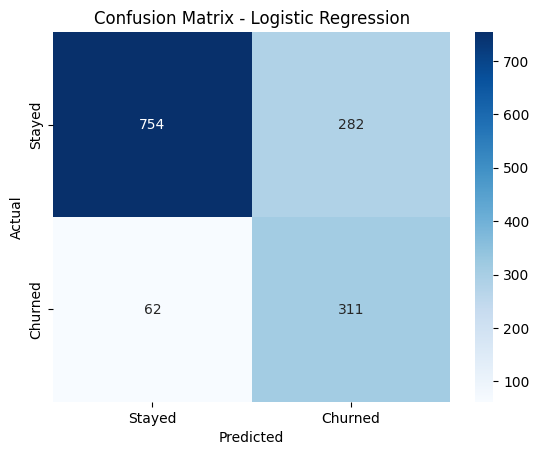

In [208]:
lr_cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0.5, 1.5], ['Stayed', 'Churned'])
plt.yticks([0.5, 1.5], ['Stayed', 'Churned'])
plt.show()

In [209]:
# Building random forest model

In [210]:
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_model.fit(X_train_balanced, y_train_balanced)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [211]:
y_pred_rf = rf_model.predict(X_test_scaled)
y_proba_rf = rf_model.predict_proba(X_test_scaled)

In [212]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_proba_rf[:, 1])

In [213]:

print(f" Random Forest - Accuracy: {accuracy_rf:.4f}")
print(f" Random Forest - ROC-AUC: {roc_auc_rf:.4f}")
print(classification_report(y_test, y_pred_rf, target_names=['Stayed', 'Churned']))

 Random Forest - Accuracy: 0.7133
 Random Forest - ROC-AUC: 0.8268
              precision    recall  f1-score   support

      Stayed       0.91      0.68      0.78      1036
     Churned       0.48      0.81      0.60       373

    accuracy                           0.71      1409
   macro avg       0.69      0.74      0.69      1409
weighted avg       0.79      0.71      0.73      1409



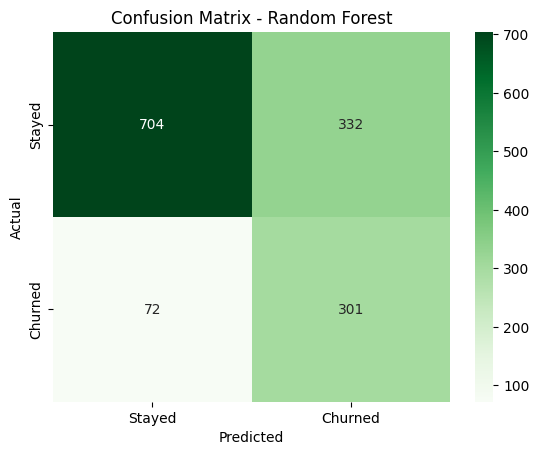

In [214]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0.5, 1.5], ['Stayed', 'Churned'])
plt.yticks([0.5, 1.5], ['Stayed', 'Churned'])
plt.show()

In [215]:
# Compare of logistic model and rf model

comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy_lr, accuracy_rf],
    'ROC-AUC': [roc_auc_lr, roc_auc_rf]})


In [216]:
comparison_df

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.755855,0.860922
1,Random Forest,0.713272,0.826762


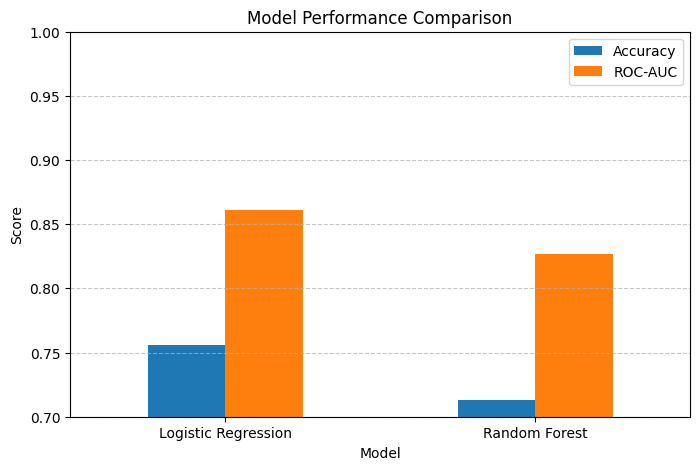

In [217]:
fig, ax = plt.subplots(figsize=(8, 5))
comparison_df.set_index('Model').plot(kind='bar', ax=ax, rot=0)
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0.7, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [218]:
# We need features that are important  from the rf model


feature_importance = pd.DataFrame({
    'feature': X_encoded.drop(columns=['tenure_group']).columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

In [219]:
print(feature_importance.head(10))

                           feature  importance
1                           tenure    0.150632
3                     TotalCharges    0.136005
2                   MonthlyCharges    0.120712
26               Contract_Two year    0.065606
4                    TotalServices    0.046034
29  PaymentMethod_Electronic check    0.044141
11     InternetService_Fiber optic    0.043604
27            PaperlessBilling_Yes    0.037003
14              OnlineSecurity_Yes    0.036730
25               Contract_One year    0.031943
